The Monte Carlo Dropout features:

- A custom MCDropout layer (always active)

- CNN model trained on MNIST

- 100 stochastic forward passes for uncertainty estimation

- Visualization of prediction variance for sample images

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Custom Dropout Layer

In [ ]:
# Custom Dropout Layer that stays active during inference
class MCDropout(layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

# CNN model

In [ ]:
# Define a simple CNN model with MC Dropout
def create_mc_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2,2)),
        MCDropout(0.3),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        MCDropout(0.3),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        MCDropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = create_mc_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 55s 61ms/step - accuracy: 0.7856 - loss: 0.6480 - val_accuracy: 0.9667 - val_loss: 0.1232
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 76s 55ms/step - accuracy: 0.9602 - loss: 0.1319 - val_accuracy: 0.9740 - val_loss: 0.0814
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9716 - loss: 0.0980 - val_accuracy: 0.9797 - val_loss: 0.0724
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9767 - loss: 0.0768 - val_accuracy: 0.9798 - val_loss: 0.0693
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.9796 - loss: 0.0685 - val_accuracy: 0.9790 - val_loss: 0.0692
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.9825 - loss: 0.0589 - val_accuracy: 0.9842 - val_loss: 0.0603
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9840 - loss: 0.0547 - val_accuracy: 0.9860 - val_loss: 0.0576
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9843 - loss: 0.0504 - 

# Monte Carlo inference

In [ ]:
# Monte Carlo inference (T stochastic forward passes)
def monte_carlo_predictions(model, x, T=100):
    preds = np.array([model(x, training=True).numpy() for _ in range(T)])
    return preds

In [ ]:
# Pick 5 test samples to run inference
x_samples = x_test[:5]
y_true = y_test[:5]
preds_mc = monte_carlo_predictions(model, x_samples, T=100)

# Mean prediction

In [ ]:
# Mean prediction and uncertainty (variance)
mean_preds = preds_mc.mean(axis=0)
std_preds = preds_mc.std(axis=0)

# Predictions and Uncertainty

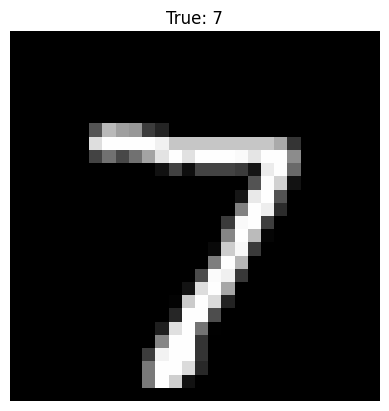

Predicted class: 7
Prediction std deviation: 0.0006



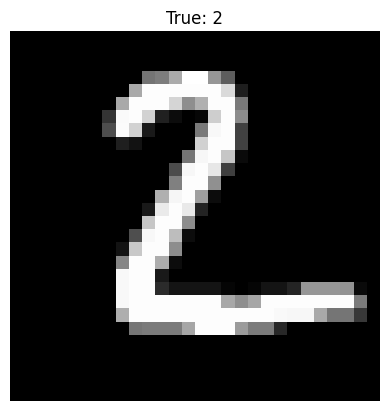

Predicted class: 2
Prediction std deviation: 0.0012



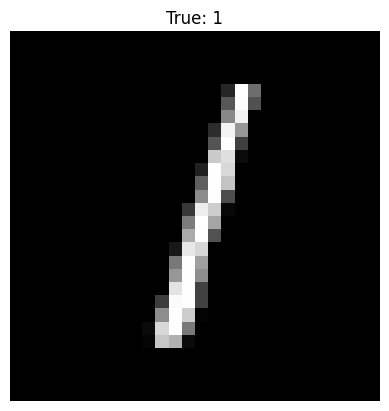

Predicted class: 1
Prediction std deviation: 0.0012



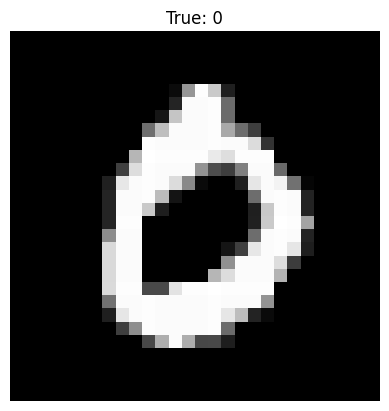

Predicted class: 0
Prediction std deviation: 0.0113



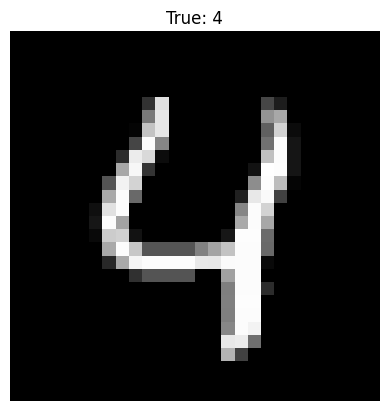

Predicted class: 4
Prediction std deviation: 0.0074



In [ ]:
# Display predictions and uncertainty
for i in range(len(x_samples)):
    plt.imshow(x_samples[i].squeeze(), cmap='gray')
    plt.title(f"True: {y_true[i]}")
    plt.axis('off')
    plt.show()

    print(f"Predicted class: {np.argmax(mean_preds[i])}")
    print(f"Prediction std deviation: {std_preds[i].max():.4f}\n")


Monte Carlo Dropout - README

📘 Overview

This Colab notebook demonstrates Monte Carlo Dropout (MC Dropout) for modeling uncertainty in neural network predictions. It modifies the standard Dropout layer to remain active during inference, allowing multiple stochastic forward passes through the model.

🧪 Objective

To implement and observe:

How MC Dropout allows us to estimate predictive uncertainty.

The difference between deterministic and stochastic inference.

Use of standard deviation to quantify confidence in predictions.

🛠️ Implementation Details

Dataset: MNIST (handwritten digit classification)

Model Architecture:

Conv2D → MaxPooling → MC Dropout

Conv2D → MaxPooling → MC Dropout

Dense → MC Dropout → Output

MC Dropout Class:

Subclass of tf.keras.layers.Dropout

Overrides call() method to always apply dropout (even during inference)

Monte Carlo Inference:

Performs T = 100 stochastic forward passes

Computes mean prediction and standard deviation

📈 Results

Each test image undergoes 100 forward passes through the model. From the predictions:

The mean class probabilities represent the predicted label.

The standard deviation shows how confident the model is about its prediction.

Key Observations:

Low standard deviation → Model is confident.

High standard deviation → Model is uncertain.

🧠 Insights

MC Dropout is a simple yet powerful technique to bring Bayesian flavor into deep learning.

Useful in safety-critical applications like medical diagnosis and autonomous driving.

Offers a non-invasive way to quantify uncertainty without changing model architecture.